# Mapping CORDIS Horizon Europe projects to SDG targets

**Registration v9, sha256 `72187842d621e55dedb6c6b366356131141cd47acf3324ab26bc7f06293c341c`, ratified by hash before any pipeline code was written.**

This notebook reads committed artefacts and recomputes nothing. Every figure and
number below comes from a file whose hash is on the cordis-sdg chain, and each
cell prints the hash of what it read. Nothing here is typed from memory.

**The finding this notebook is built around is a ceiling, not a score.** Of the
95 (project, target) pairs the held-out reference contains, **53 have no lexical
or crosswalk evidence in the project's own text at all**. No threshold reaches
them. Recall of 0.221 is therefore *half of what this method could ever reach*,
and the gap between 0.442 and 1.0 is the cost of the registration's rule that a
mapping decision is made by rules a reader can run by hand and never by a model.

The dependencies here are the notebook's alone. **The pipeline, the vocabulary
build, the crosswalk verifier, the guard and the metrics are pure standard
library**, and none of them needs anything in `requirements-notebook.txt`.

In [1]:
import hashlib, json, pathlib, csv
import matplotlib
%config InlineBackend.figure_formats = ['svg']
# DETERMINISM, because everything else here is checked by hash and a figure
# that changes on every run cannot be. Matplotlib's SVG writer embeds a
# <dc:date> and derives element ids from a per-process random salt, so two
# runs of this notebook produced six figures that differed in 30 lines each
# and in nothing anyone could see. Both are pinned here.
matplotlib.rcParams['svg.hashsalt'] = 'cordis-sdg'
%config InlineBackend.print_figure_kwargs = {'metadata': {'Date': None}}
SVG = dict(format='svg', bbox_inches='tight', metadata={'Date': None})
import matplotlib.pyplot as plt

ROOT = pathlib.Path.cwd()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent            # executed from notebooks/
FIGDIR = ROOT / "figures"
FIGDIR.mkdir(exist_ok=True)

def read(rel):
    """Read a committed artefact and print the hash of the bytes just read.

    Not the hash recorded somewhere about this file: the hash of what this
    cell opened. That is the difference between provenance and a caption."""
    p = ROOT / rel
    b = p.read_bytes()
    print("%-44s %s" % (rel, hashlib.sha256(b).hexdigest()))
    return json.loads(b.decode("utf-8"))

metrics = read("data/pipeline/evaluation-100-metrics.json")
figures = read("data/corpus/figures.json")
params  = read("data/pipeline/parameters-v1.json")
print()
print("registration      ", metrics["registration_sha256"])
print("pipeline commit   ", figures["pipeline_commit"])
print("parameters frozen at seq", params["_frozen"]["freeze_seq"], "values", metrics["parameters_values_sha256"])
print("mapping table     ", figures["mapping_table_sha256"])

data/pipeline/evaluation-100-metrics.json    babd37415581ce82ecb09c4501052ce811e834e57dad7c6735389ce321dd8a2e
data/corpus/figures.json                     03d79580081ca40bf0d1d25b5279a57880ddf09d750490553593387126d92f6f
data/pipeline/parameters-v1.json             4a15d80f9040981d27a0977bef00251d384dedbb18e2b7460bb55d6d9f8cf834

registration       72187842d621e55dedb6c6b366356131141cd47acf3324ab26bc7f06293c341c
pipeline commit    0246412b44f722567feaa2e6c1b6e695de86c923
parameters frozen at seq 207 values 3808845b553dfda751bf4a3e5c87bd17f32b6ca8c195a0c54321ed25e03e09e1
mapping table      181d378a3078014193f3ae4f684b00b375ed62f3d24b2b34c060f6457b4a00d3


## 1. Method

**The mapping decision is made by rules a reader can run by hand.** A language
model writes the explanation of a decision already made; it never makes one.
Nothing in the scoring path calls a model.

Two load-bearing artefacts, both built before any project text was scored:

| | |
|---|---|
| **Crosswalk** | EuroSciVoc category → SDG target, every row with a one-line justification citing the target's own text, reviewed before use |
| **Vocabulary** | key terms extracted from target labels by a committed written rule, plus a curated synonym list, a stop-list and a negation rule |

**Neither was derived from project text.** The crosswalk was built from the
category vocabulary on one side and the taxonomy's target labels on the other;
the only project data consulted was the list of distinct category paths, which
is the table's own left-hand side. That is what makes the held-out set worth
anything, and it is checkable rather than asserted: `verify_crosswalk.py` reads
the same two sources and nothing else.

**Validation was registered before it was run.** One seeded draw of 150
projects, split 50 development and 100 evaluation. Parameters are tuned on the
50 and frozen by the owner's word before the 100 is scored. The evaluation
labels are sealed *and unread* until the frozen pipeline has run once on the 100
and its output hash is posted.

## 2. Data preparation

**One dataset, four distributions, because no single one carries the fields the
registration matches on.** The projects extract has the objective, title and
keywords; the deliverables extract has per-deliverable descriptions; the
editorial description lives only in the reports JSON, in four narrative fields.
All four are hashed in `data/manifest.json`.

**The snapshot is not one upstream moment and does not claim to be.** The
projects extract was last modified upstream eight days after the other three,
and the four were retrieved at three local moments.

**A standard CSV reader gets `project.csv` wrong.** CORDIS under-escapes any
field whose content *begins* with a quotation mark, writing two quote characters
where three are needed. Measured across every field: **994 rows (4.24%) have at
least one such field; a standard reader breaks 193 of them outright and silently
alters 801 more**, dropping the character. Every read of that file goes through
`scripts/read_projects.py`, which splits on the literal separator instead.

**Labellers and the pipeline read the same text, gaps included.** Both work from
the hand-off artefact, where every field is present on every record and an
absent field carries the literal string `(absent)` and is listed in that
record's `absent_fields`. A labeller who cannot tell "this project has no
editorial description" from "this field was not included" reads the same gap two
ways on two different projects.

## 3. Mapping logic

Evidence for a (project, target) pair comes from six independent channels: the
five text fields, and the reviewed crosswalk. Each match is recorded as the
exact phrase found with its source field.

The weights below were tuned on the development 50 and frozen. Two properties
are worth naming because they are choices rather than arithmetic:

- **A single reviewed crosswalk row reaches the threshold on its own; a single
  lexical phrase never does.** One reviewed discipline-level claim is evidence;
  one word is not.
- **A *contributing* crosswalk row counts at most once per target.** Two rows
  each saying "a route to the target, not its subject" would otherwise sum to
  exactly one *direct* row, which is arithmetic standing in for a reviewed
  judgement.

In [2]:
w = params["evidence_weights"]
print("parameters version", params["version"], "— frozen at cordis-sdg seq", params["_frozen"]["freeze_seq"])
print()
for k, v in w.items():
    if not k.startswith("_"):
        print("  %-30s %s" % (k, v))
a = params["assignment"]
print()
print("  threshold                      %s" % a["threshold"])
print("  requires discriminating        %s" % a["requires_discriminating_evidence"])
print("  cap on targets per project     %s" % a["max_targets_per_project"])
for band in ("high", "medium", "low"):
    b = params["confidence_bands"][band]
    print("  band %-8s score >= %-4s and >= %s independent sources"
          % (band, b["min_score"], b["min_independent_sources"]))

parameters version v2 — frozen at cordis-sdg seq 207

  crosswalk_direct               3.0
  crosswalk_contributing         1.5
  synonym_subject                2.0
  synonym_domain                 1.5
  synonym_policy                 1.5
  synonym_acronym                1.5
  key_term_multi_word            1.0
  key_term_single_word           0.5
  key_term_not_discriminating    0.25

  threshold                      3.0
  requires discriminating        True
  cap on targets per project     5
  band high     score >= 6.0  and >= 3 independent sources
  band medium   score >= 4.5  and >= 2 independent sources
  band low      score >= 3.0  and >= 1 independent sources


## 4. Results on the development and evaluation sets

**The development 50 is reported and is not the headline.** It is what the
parameters were tuned against, so it cannot measure the method.

Two labellers worked the development set, each set uploaded and hashed before
either was revealed. Their agreement is the scale against which the pipeline's
precision should be read: **two careful labellers do not fully agree about what
a project is about.**

In [3]:
proof = metrics["self_proof_against_seq_129"]
t, g = proof["target_level"], proof["goal_level_secondary"]
print("DEVELOPMENT 50 — inter-rater agreement, %s against %s" % (proof["first_labeller"], proof["second_labeller"]))
print("  both assigned %-4d  only first %-4d  only second %-4d  neither %d"
      % (t["both_assigned"], t["only_first"], t["only_second"], t["neither"]))
print("  target level   agreement %.4f   Cohen's kappa %.3f   Jaccard %.3f"
      % (t["agreement_rate"], t["cohens_kappa"], t["jaccard"]))
print("  goal level     agreement %.4f   Cohen's kappa %.3f"
      % (g["agreement_rate"], g["cohens_kappa"]))
print()
ev, eg = metrics["target_level"], metrics["goal_level_secondary"]
ref = metrics["reference"]
print("EVALUATION 100 — pipeline against %s" % ref["labeller"])
print("  reference %d pairs over %d projects, %d projects with no target"
      % (ref["pairs"], ref["projects"], ref["projects_with_no_target"]))
for name, m in (("target level", ev), ("goal level", eg)):
    print("  %-13s tp %-3d fp %-3d fn %-3d   precision %.3f  recall %.3f  F1 %.3f"
          % (name, m["true_positives"], m["false_positives"], m["false_negatives"],
             m["precision"], m["recall"], m["f1"]))

DEVELOPMENT 50 — inter-rater agreement, Hermes Cordis (identity ph-9c11aec45467c4d6) against Claude Chat (counsel), identity ph-b50aa7262165a51b
  both assigned 52    only first 14    only second 35    neither 8349
  target level   agreement 0.9942   Cohen's kappa 0.677   Jaccard 0.515
  goal level     agreement 0.9741   Cohen's kappa 0.806

EVALUATION 100 — pipeline against Hermes Cordis (identity ph-9c11aec45467c4d6)
  reference 95 pairs over 100 projects, 31 projects with no target
  target level  tp 21  fp 26  fn 74    precision 0.447  recall 0.221  F1 0.296
  goal level    tp 29  fp 42  fn 50    precision 0.408  recall 0.367  F1 0.387


### Two of the registration's four evaluation figures do not exist

The registration provided for **20 of the 100 to be hand-labelled by the owner**
as a human anchor. **They were never made.** That removes the evaluation set's
inter-rater agreement entirely — one labeller cannot disagree with himself — and
it removes the anchor. No substitute is offered for either: comparing the
labeller to the pipeline would be the pipeline's own accuracy reported a second
time under a name that implies two humans.

**No human labelled anything in this study.** Every label on both sets was made
by a language-model seat.

## 5. The recall ceiling — the finding

A recall number invites the reading that tuning would fix it. **Here it would
not**, and that is measurable rather than arguable: for each pair the reference
contains, ask whether the pipeline found *any* evidence for that target in that
project at all, at any score. A pair with none is not recoverable by lowering a
threshold, reweighting, or any other tuning move.

reference pairs                      95
  with some evidence                 42
  with NO evidence at any threshold  53
  ceiling                            0.4421
  recall achieved                    0.2211
  achieved as a share of the ceiling 50.0%



wrote figures/recall-ceiling.svg


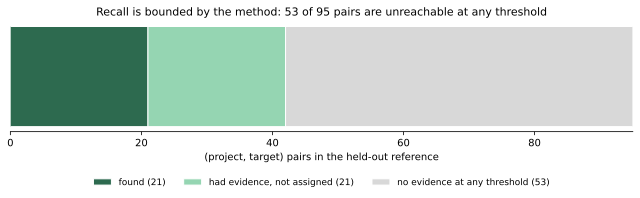

In [4]:
rc = metrics["recall_ceiling"]
print("reference pairs                      %d" % rc["reference_pairs"])
print("  with some evidence                 %d" % rc["with_some_evidence"])
print("  with NO evidence at any threshold  %d" % rc["with_no_evidence_at_any_threshold"])
print("  ceiling                            %.4f" % rc["ceiling"])
print("  recall achieved                    %.4f" % ev["recall"])
print("  achieved as a share of the ceiling %.1f%%" % (100 * ev["recall"] / rc["ceiling"]))

fig, ax = plt.subplots(figsize=(9, 3.2))
found = ev["true_positives"]
reachable_missed = rc["with_some_evidence"] - found
unreachable = rc["with_no_evidence_at_any_threshold"]
parts = [(found, "#2d6a4f", "found (%d)" % found),
         (reachable_missed, "#95d5b2", "had evidence, not assigned (%d)" % reachable_missed),
         (unreachable, "#d8d8d8", "no evidence at any threshold (%d)" % unreachable)]
left = 0
for value, colour, label in parts:
    ax.barh([0], [value], left=left, color=colour, edgecolor="white", label=label)
    left += value
ax.set_yticks([])
ax.set_xlim(0, rc["reference_pairs"])
ax.set_xlabel("(project, target) pairs in the held-out reference")
ax.set_title("Recall is bounded by the method: %d of %d pairs are unreachable at any threshold"
             % (unreachable, rc["reference_pairs"]), fontsize=11)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False, fontsize=9)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(FIGDIR / "recall-ceiling.svg", **SVG)
print("\nwrote figures/recall-ceiling.svg")
plt.show()

**The held-out set behaves like the set the method was tuned on.** The
development ceiling is 0.446 over the union of two label sets and the evaluation
ceiling is 0.442 over one labeller. Those are not like for like and the
closeness is evidence about the method's reach, not a controlled comparison.

**The failure is silence, not noise.** Of the 64 projects where the pipeline and
the reference disagree, the great majority are cases where the pipeline found
nothing the labeller found, rather than cases where it invented something.

wrote figures/disagreement-shape.svg


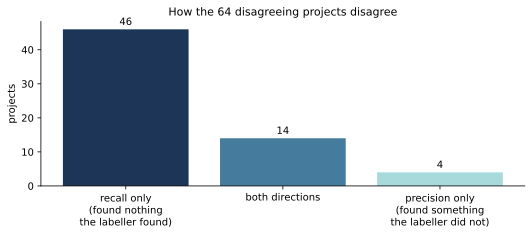

In [5]:
shape = figures["where_the_mapping_is_uncertain"]["disagreement_shape_on_the_evaluation_100"]
labels = ["recall only\n(found nothing\nthe labeller found)",
          "both directions",
          "precision only\n(found something\nthe labeller did not)"]
values = [shape["recall_only"], shape["both_directions"], shape["precision_only"]]
fig, ax = plt.subplots(figsize=(7.5, 3.4))
bars = ax.bar(labels, values, color=["#1d3557", "#457b9d", "#a8dadc"])
ax.bar_label(bars, padding=2)
ax.set_ylabel("projects")
ax.set_title("How the %d disagreeing projects disagree" % shape["projects_disagreeing"], fontsize=11)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(FIGDIR / "disagreement-shape.svg", **SVG)
print("wrote figures/disagreement-shape.svg")
plt.show()

## 6. The whole snapshot

The frozen pipeline was run over all **23,451** projects to build the submission
table. The counts below are from that run.

In [6]:
shape = figures["corpus_shape"]
total = figures["coverage"]["projects_in_table"]
print("projects            %d" % total)
print("  with a target     %5d  (%.1f%%)" % (shape["projects_with_a_target"], 100*shape["projects_with_a_target"]/total))
print("  goal level only   %5d  (%.1f%%)" % (shape["projects_goal_level_only"], 100*shape["projects_goal_level_only"]/total))
print("  nothing at all    %5d  (%.1f%%)" % (shape["projects_unassigned"], 100*shape["projects_unassigned"]/total))
print("rows in the table   %d" % shape["rows"])
print()
print("targets in the taxonomy      %d" % figures["least_linked_targets"]["targets_in_taxonomy"])
print("targets never assigned       %d" % len(figures["least_linked_targets"]["targets_never_assigned"]))
print("goals never assigned         %s" % (figures["goals_never_assigned"] or "none — all 17 are reached"))

projects            23451
  with a target      9394  (40.1%)
  goal level only    6882  (29.3%)
  nothing at all     7175  (30.6%)
rows in the table   28833

targets in the taxonomy      169
targets never assigned       33
goals never assigned         none — all 17 are reached


wrote figures/goals-by-project-count.svg


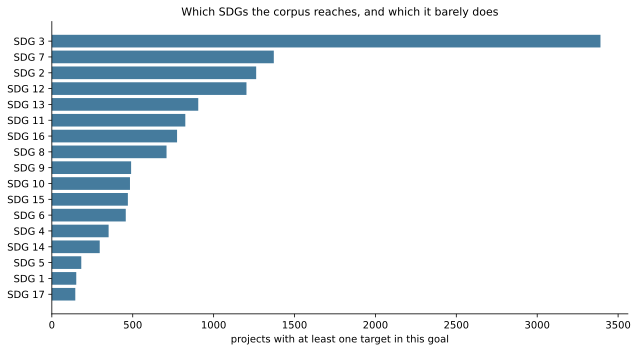

In [7]:
goals = sorted(figures["goals_by_project_count"], key=lambda d: -d["projects"])
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(["SDG %s" % d["goal_id"] for d in goals][::-1],
        [d["projects"] for d in goals][::-1], color="#457b9d")
ax.set_xlabel("projects with at least one target in this goal")
ax.set_title("Which SDGs the corpus reaches, and which it barely does", fontsize=11)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(FIGDIR / "goals-by-project-count.svg", **SVG)
print("wrote figures/goals-by-project-count.svg")
plt.show()

wrote figures/most-linked-targets.svg


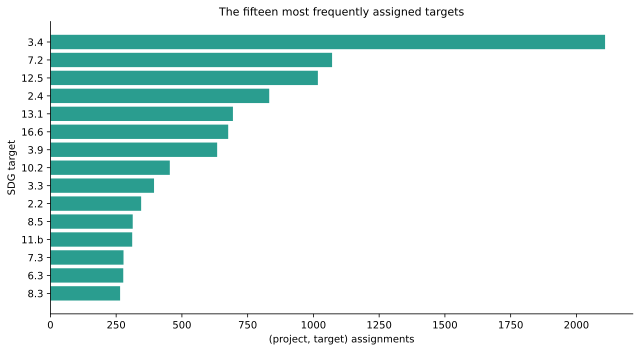

In [8]:
top = figures["most_linked_targets"][:15]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([d["key"] for d in top][::-1], [d["count"] for d in top][::-1], color="#2a9d8f")
ax.set_xlabel("(project, target) assignments")
ax.set_ylabel("SDG target")
ax.set_title("The fifteen most frequently assigned targets", fontsize=11)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(FIGDIR / "most-linked-targets.svg", **SVG)
print("wrote figures/most-linked-targets.svg")
plt.show()

wrote figures/relevance-by-field.svg
  humanities                        1882 projects,   539 with a target, 28.6%
  natural sciences                 13296 projects,  5093 with a target, 38.3%
  engineering and technology        6579 projects,  3224 with a target, 49.0%
  social sciences                   5340 projects,  3007 with a target, 56.3%
  medical and health sciences       5045 projects,  2897 with a target, 57.4%
  agricultural sciences             1390 projects,  1134 with a target, 81.6%


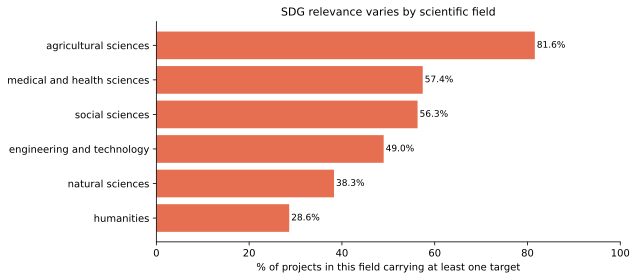

In [9]:
fields = [d for d in figures["by_scientific_field"] if d["key"] != "(absent)"]
fields.sort(key=lambda d: d["rate"])
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh([d["key"] for d in fields], [100*d["rate"] for d in fields], color="#e76f51")
ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=9)
ax.set_xlabel("% of projects in this field carrying at least one target")
ax.set_xlim(0, 100)
ax.set_title("SDG relevance varies by scientific field", fontsize=11)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(FIGDIR / "relevance-by-field.svg", **SVG)
print("wrote figures/relevance-by-field.svg")
for d in fields:
    print("  %-32s %5d projects, %5d with a target, %.1f%%"
          % (d["key"], d["projects"], d["with_a_target"], 100*d["rate"]))
plt.show()

wrote figures/confidence-bands.svg
{'high': 2625, 'medium': 2923, 'low': 9228}


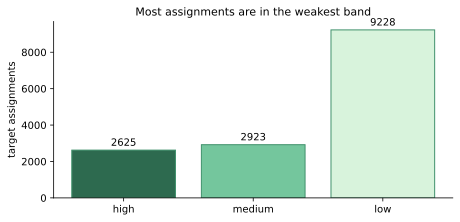

In [10]:
bands = {d["key"]: d["count"] for d in figures["confidence_bands"]}
order = [b for b in ("high", "medium", "low") if b in bands]
fig, ax = plt.subplots(figsize=(6.5, 3.2))
bars = ax.bar(order, [bands[b] for b in order], color=["#2d6a4f", "#74c69d", "#d8f3dc"][:len(order)],
              edgecolor="#40916c")
ax.bar_label(bars, padding=2)
ax.set_ylabel("target assignments")
ax.set_title("Most assignments are in the weakest band", fontsize=11)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(FIGDIR / "confidence-bands.svg", **SVG)
print("wrote figures/confidence-bands.svg")
print({k: bands[k] for k in order})
plt.show()

## 7. Limitations

**The evaluation reference is one automated labeller working blind.** The owner's
20 hand-labels were never made, so there is no inter-rater figure on the
evaluation set and no human anchor, and the pre-registered adjudication rule
makes that labeller's set the sole reference for all 100 rather than for 80.

**No human labelled anything in this study.**

**Recall is bounded at 0.442 by the method**, not by its settings. 53 of 95
reference pairs have no evidence at any threshold.

**30.6% of the corpus receives no assignment at all** — 7,175 of 23,451
projects — and 33 of the 169 targets are never assigned anywhere.

**Most assignments sit in the weakest confidence band.**

**Four fifths of the EuroSciVoc vocabulary is deliberately unmapped**, because no
defensible one-line justification exists against any target's text. Inventing one
would produce exactly the superficial mapping that a quality criterion penalises.

**The explanation pass is parked.** No model credential is set in this
environment and the registration forbids one in the repository or the room, so
the pass records its prompts with their hashes and writes nothing that pretends
to be a model's work. The `explanation` and `prompt_sha256` columns of the
mapping table say so on every row rather than being blank.

**There is no acceptance threshold.** This is a report of what the method does,
not a gate it passed.

In [11]:
print("figures written, and committed as SVG for the prototype:")
for p in sorted(FIGDIR.glob("*.svg")):
    b = p.read_bytes()
    print("  %-32s %6.1f KB  %s" % (p.name, len(b)/1024, hashlib.sha256(b).hexdigest()[:16]))

figures written, and committed as SVG for the prototype:
  confidence-bands.svg               25.7 KB  f1ed073c644e2f30
  disagreement-shape.svg             32.0 KB  8a341c1c2d30f974
  goals-by-project-count.svg         45.0 KB  aa78ad6899991370
  most-linked-targets.svg            42.4 KB  b3c454183a22a771
  recall-ceiling.svg                 36.8 KB  05954958126b5a32
  relevance-by-field.svg             44.0 KB  d867a25c86bac793
